#Notebook Overview

This notebook runs the full adaptive compression pipline and benchmarks it againts standard JPEG. It generates rate-distortion curves across Q=10-80, evaluates per-image performance on the full 137-image test set, and computes compression ratios. This is the primary results notebook - run after 01_train_model.ipynb and 02_test_model.ipynb.

# Library and Package Imports


In [1]:
# Install PyTorch for deep learning model
!pip install torch torchvision

# Install image processing and utility libraries
!pip install numpy opencv-python matplotlib tqdm

import numpy as np          # numerical operations and array handling
import pandas as pd
import cv2 as cv            # image processing and JPEG operations
import random               # random sampling and testing
import matplotlib.pyplot as plt  # image visualization
from PIL import Image       # image loading and saving
import io                   # in-memory image handling
import os                   # file and directory operations

import torch                # core PyTorch library
import torch.nn as nn       # neural network layers and models
import torch.nn.functional as F  # activation and functional operations

from tqdm import tqdm       # progress bar for loops


# Dataset Loading and Test Split

Load HR and LR image pairs from Google Drive and split the dataset (80–20).
The last 20% is used as the test set for evaluation.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset

hr_images = np.load("/content/drive/MyDrive/imagecompression/hr_images.npy")
lr_images = np.load("/content/drive/MyDrive/imagecompression/lr_images.npy")

# Split into test set (last 20%)
split_idx = int(0.8 * len(hr_images))
test_hr = hr_images[split_idx:]
test_lr = lr_images[split_idx:]

print("Test size:", len(test_hr))

assert len(hr_images) == len(lr_images), "Mismatch in dataset sizes"


Test size: 137


In [4]:
print(f"Total images: {len(hr_images)}")
print(f"Split index: {int(0.8 * len(hr_images))}")
print(f"Test size: {len(test_hr)}")
print(f"First test image shape: {test_hr[0].shape}")

Total images: 685
Split index: 548
Test size: 137
First test image shape: (256, 256, 3)


#Dataset Visualization (HR and LR Images)

Displays sample high-resolution (HR) and low-resolution (LR) images from the dataset to verify data quality and understand the difference between inputs used by the model.

Displaying high resolution images:



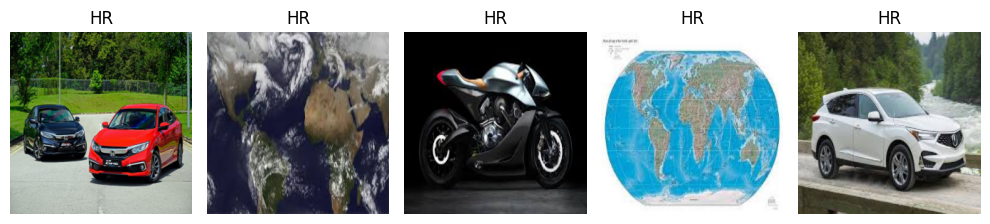


Displaying low resolution images:



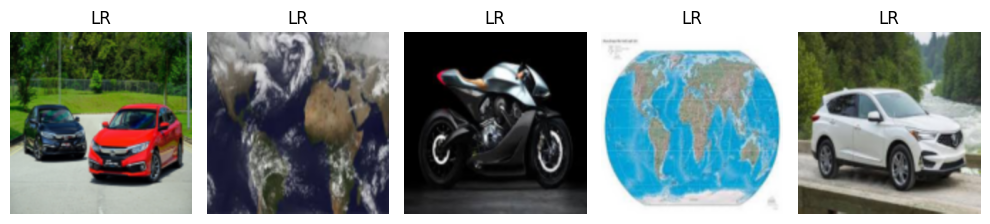

In [5]:
# Reusable function to display images
def display_images(images, title, num_images=5):
    plt.figure(figsize=(10, 4))  # set figure size

    for i in range(min(num_images, len(images))):
        plt.subplot(1, num_images, i + 1)   # create subplot
        plt.imshow(images[i])               # display image
        plt.axis('off')                     # remove axes
        plt.title(f"{title}", fontsize=12)  # label with type

    plt.tight_layout()
    plt.show()


# Display HR images
print("Displaying high resolution images:\n")
display_images(hr_images, "HR", num_images=5)

# Display LR images
print("\nDisplaying low resolution images:\n")
display_images(lr_images, "LR", num_images=5)

# Defining U-Net Architecture

Implements a U-Net architecture that takes a 6-channel input (concatenated HR and LR images) and predicts a single-channel importance map. The encoder progressively downsamples the input to capture higher-level features, while the decoder upsamples and reconstructs spatial detail.

Skip connections between encoder and decoder layers help preserve fine-grained information, which is important for accurately identifying visually significant regions. The final output is passed through a sigmoid activation to produce a normalized importance map in the range [0, 1].


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        # Encoder: progressively downsample and extract features
        self.enc1 = self.conv_block(6, 32)
        self.enc2 = self.conv_block(32, 64)
        self.enc3 = self.conv_block(64, 128)

        # Bottleneck: deepest representation
        self.bottleneck = self.conv_block(128, 256)

        # Decoder: upsample and combine with encoder features (skip connections)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = self.conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = self.conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = self.conv_block(64, 32)

        # Output: single-channel importance map
        self.final = nn.Conv2d(32, 1, 1)

    def conv_block(self, in_c, out_c):
        # basic conv block: Conv → BN → ReLU (x2)
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder path
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e3, 2))

        # Decoder path with skip connections
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # final output in [0, 1]
        return torch.sigmoid(self.final(d1))

# Importance Map Normalization

Normalizes the importance map so values are relative and stable, clamps extreme values, and smooths it to reduce noise. This ensures consistent and meaningful importance for adaptive compression.

In [7]:
def normalize_importance(importance):
    # Normalize by mean to keep relative importance (center ~1)
    importance = importance / (importance.mean(dim=[1,2,3], keepdim=True) + 1e-6)

    # Limit extreme values for stability
    importance = torch.clamp(importance, 0.1, 2.0)

    # Smooth map to reduce noise
    importance = F.avg_pool2d(importance, kernel_size=3, stride=1, padding=1)

    return importance

# Model Loading and Setup

Initializes the device (GPU if available), loads the trained U-Net model, and prepares it for inference.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # select device

model = UNet().to(device)  # initialize model
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/imagecompression/best_model.pth",
    map_location=device
))  # load trained weights

model.eval()  # set model to evaluation mode
print("Model loaded successfully")

Model loaded successfully


# Importance Map Generation

Generates an importance map from HR and LR images by passing them through the trained model. The output is normalized to ensure consistency with training.

In [9]:
def get_importance_map(hr, lr):
    # Combine HR and LR inputs and normalize
    img = np.concatenate([hr/255.0, lr/255.0], axis=2)

    # Convert to tensor (C, H, W) and move to device
    tensor = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).float().to(device)

    # Inference (no gradient computation)
    with torch.no_grad():
        imp = model(tensor)                  # predict importance
        imp = normalize_importance(imp)      # normalize output

    return imp.squeeze().cpu().numpy()       # convert to numpy

# Importing Compression Utilities

Evaluates the trained model on test images by generaing importance maps and visualizing where the model focuses. Used to verify that the model model correctly highlights visually significant regions for adaptive compression.

In [10]:
#Adds the project directory to the Python path to enable importing custom utility functions.

import sys
sys.path.append('/content/drive/MyDrive/imagecompression')
import compression_utils as cu

# Per-Image Rate–Distortion Analysis

Evaluates adaptive and standard JPEG compression across multiple quality levels for 25 test images. For each image, RMSE and bitrate (BPP) are recorded and plotted to analyze how compression performance varies per image.


Processing quality 10


Quality 10: 100%|██████████| 25/25 [00:10<00:00,  2.30it/s]



Processing quality 20


Quality 20: 100%|██████████| 25/25 [00:07<00:00,  3.25it/s]



Processing quality 30


...

Quality 60: 100%|██████████| 25/25 [00:10<00:00,  2.40it/s]



Processing quality 70


Quality 70: 100%|██████████| 25/25 [00:11<00:00,  2.26it/s]



Processing quality 80


Quality 80: 100%|██████████| 25/25 [00:13<00:00,  1.90it/s]


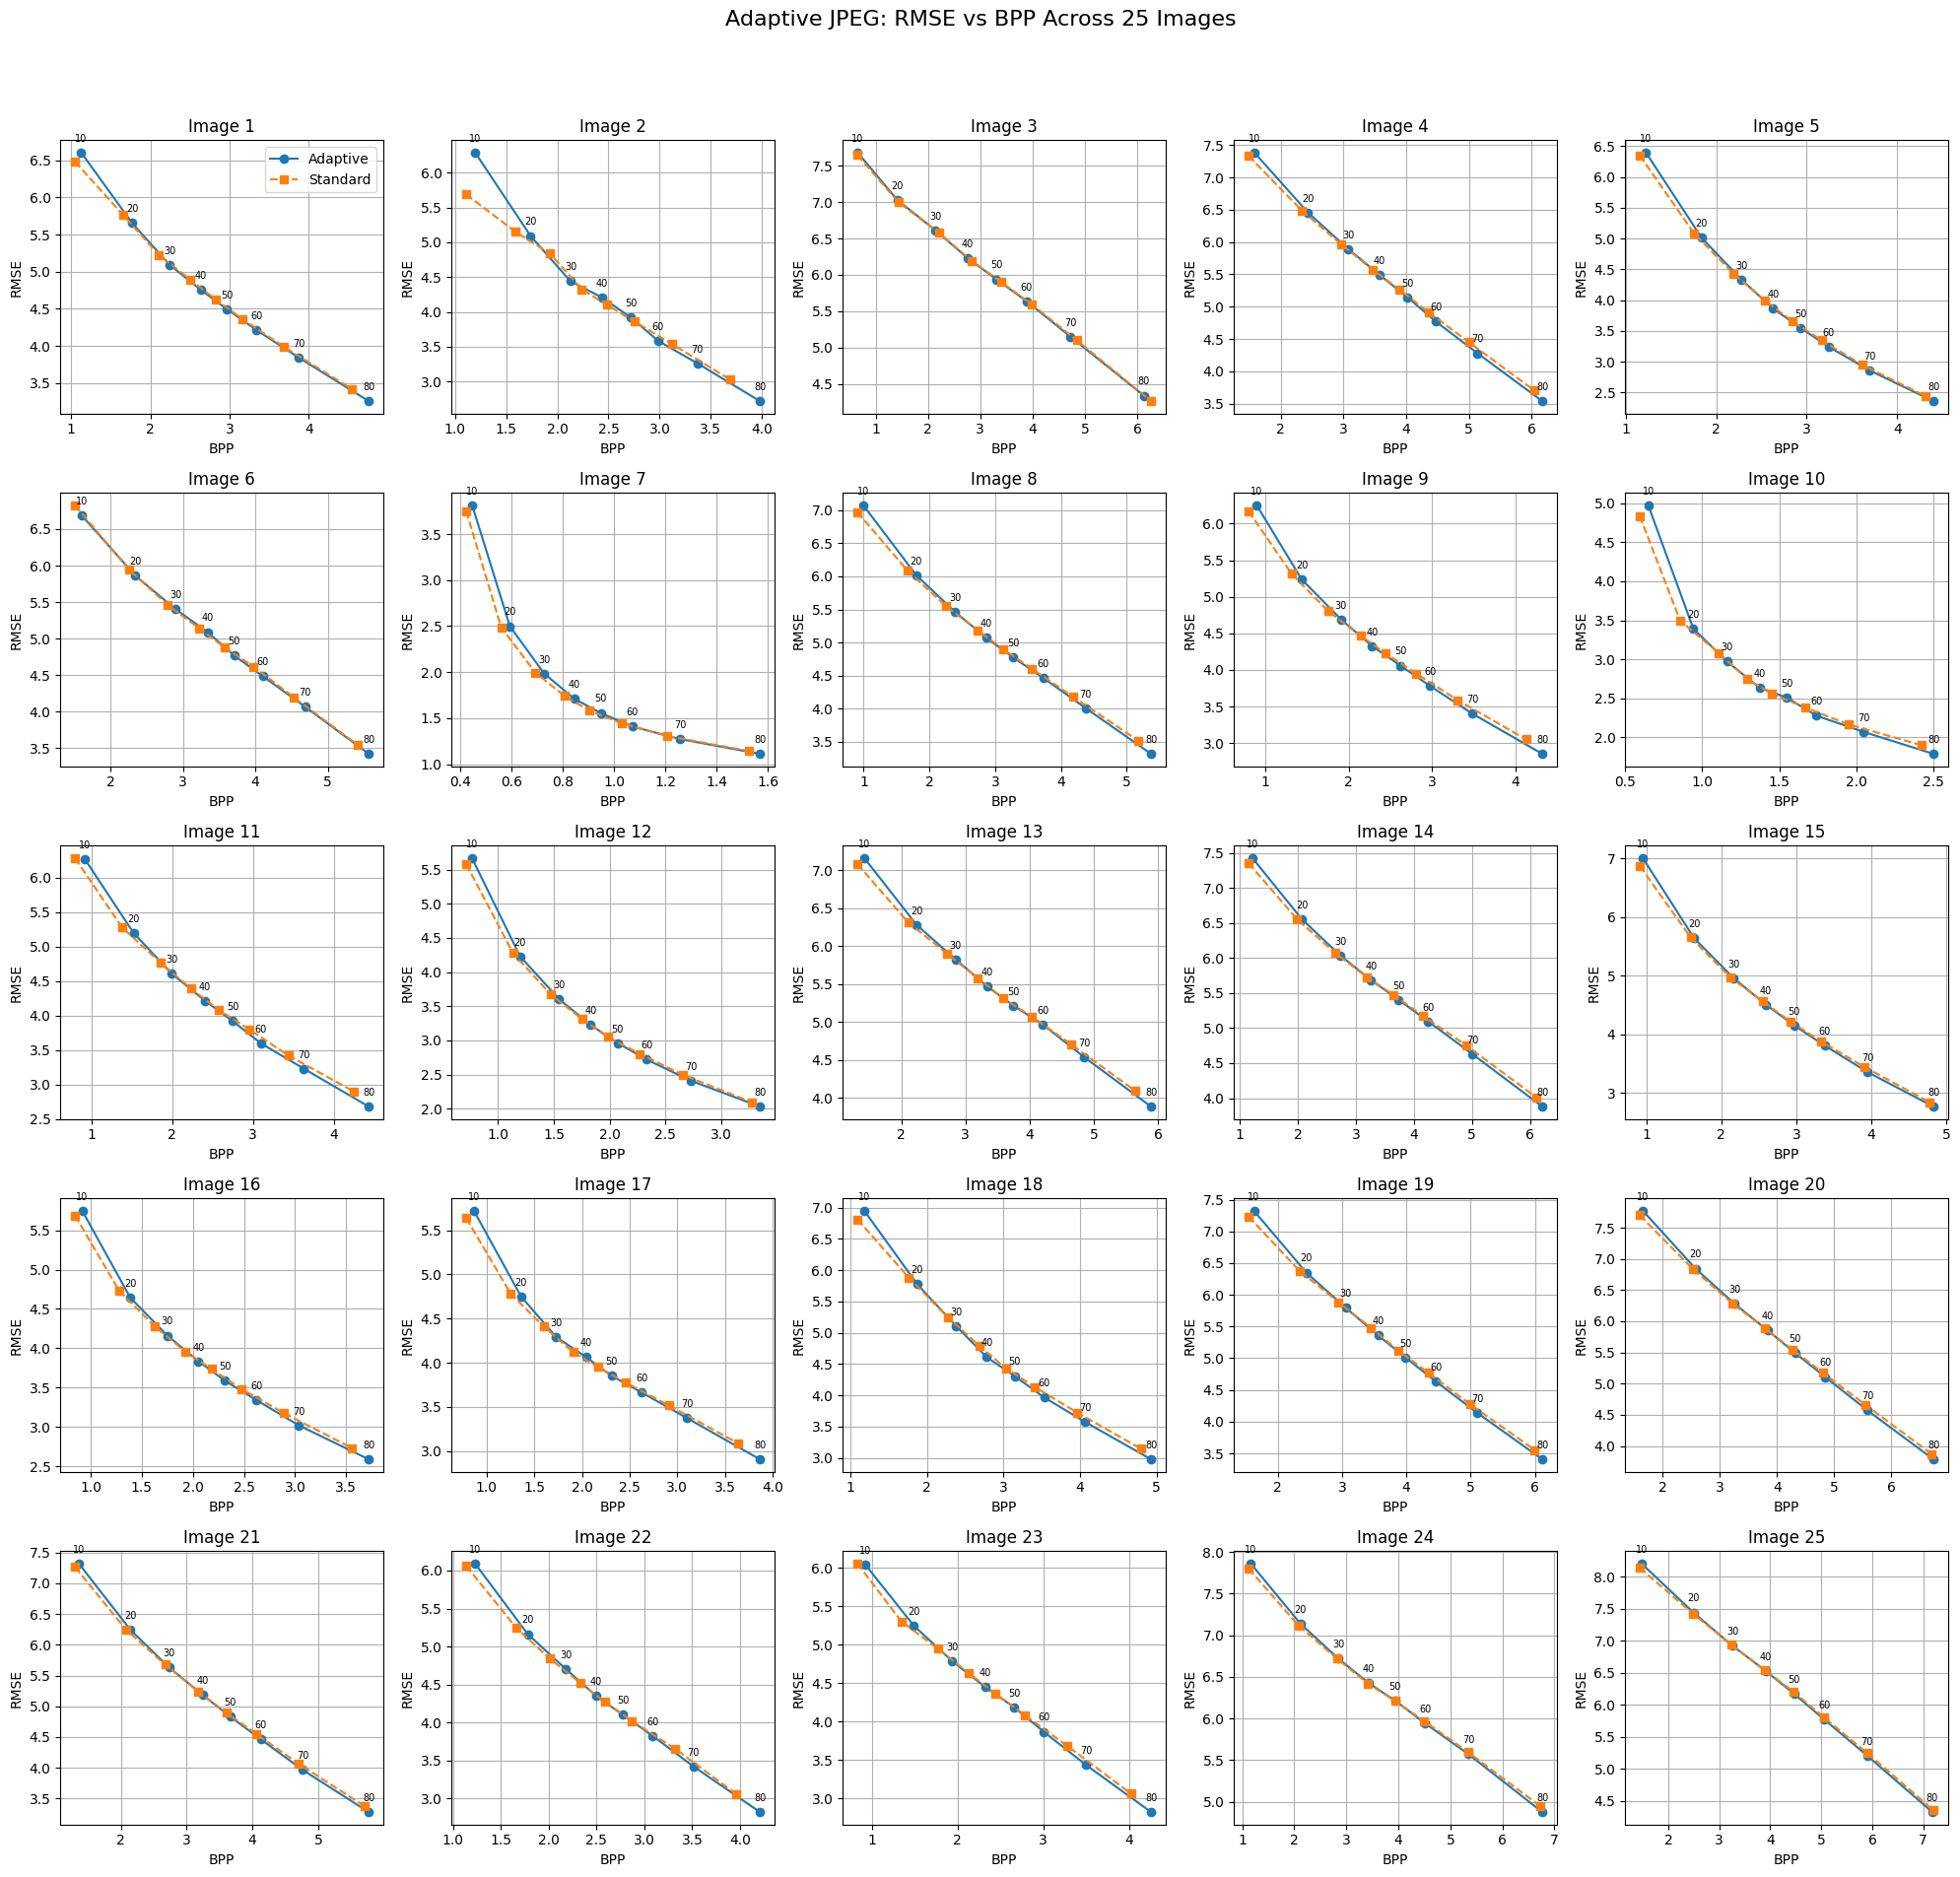

In [11]:
# Select subset of test images
images_to_process = list(zip(test_hr[:25], test_lr[:25]))

# Store results for standard JPEG
std_rmse_values = [[] for _ in range(len(images_to_process))]
std_bpp_values = [[] for _ in range(len(images_to_process))]

# Quality levels to test
quality_factors = [10, 20, 30, 40, 50, 60, 70, 80]

# Store results for adaptive method
individual_rmse_values = [[] for _ in range(len(images_to_process))]
individual_bpp_values = [[] for _ in range(len(images_to_process))]

# Loop over quality levels
for quality in quality_factors:
    print(f"\nProcessing quality {quality}")

    for i, (hr, lr) in enumerate(tqdm(images_to_process, desc=f"Quality {quality}")):

        # -------- Adaptive JPEG --------
        importance_map = get_importance_map(hr, lr)  # predict importance

        processed_image, total_encoded_bits = cu.process_image_bitrate_neutral(
            hr, quality, importance_map, alpha=1.0
        )

        rmse_adp = cu.calculate_rmse(hr, processed_image)
        bpp_adp = total_encoded_bits / (hr.shape[0] * hr.shape[1])

        individual_rmse_values[i].append(rmse_adp)
        individual_bpp_values[i].append(bpp_adp)

        # -------- Standard JPEG --------
        std_img, bits_std = cu.process_image_standard(hr, quality)

        rmse_std = cu.calculate_rmse(hr, std_img)
        bpp_std = bits_std / (hr.shape[0] * hr.shape[1])

        std_rmse_values[i].append(rmse_std)
        std_bpp_values[i].append(bpp_std)

# Plotting Per-Image RD Curves
fig, axs = plt.subplots(5, 5, figsize=(20, 20))
fig.suptitle('Adaptive JPEG: RMSE vs BPP Across 25 Images', fontsize=16)

axs = axs.flatten()

for i in range(len(images_to_process)):
    # Adaptive curve
    axs[i].plot(individual_bpp_values[i], individual_rmse_values[i],
                marker='o', label='Adaptive')

    # Standard JPEG curve
    axs[i].plot(std_bpp_values[i], std_rmse_values[i],
                marker='s', linestyle='--', label='Standard')

    axs[i].set_xlabel('BPP')
    axs[i].set_ylabel('RMSE')
    axs[i].set_title(f'Image {i+1}')
    axs[i].grid(True)

    if i == 0:
        axs[i].legend()

    # Annotate quality levels
    for j, q in enumerate(quality_factors):
        axs[i].annotate(q,
                        (individual_bpp_values[i][j], individual_rmse_values[i][j]),
                        textcoords="offset points",
                        xytext=(0, 8),
                        ha='center',
                        fontsize=7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save figure
plt.savefig("/content/drive/MyDrive/imagecompression/per_image_rd.png", dpi=100)

plt.show()

# Rate–Distortion (RD) Curve Evaluation

Evaluates compression performance across multiple quality levels by computing average bitrate (BPP) and PSNR for both adaptive and standard JPEG. Precomputed importance maps are reused to ensure efficient evaluation.

In [12]:
qualities = [10, 20, 30, 40, 50, 60, 70, 80]

# Precompute importance maps (efficient)
print("Precomputing importance maps...")
importance_maps = []
for hr, lr in zip(test_hr[:25], test_lr[:25]):
    imp = get_importance_map(hr, lr)
    importance_maps.append(imp)
print(f"Done. {len(importance_maps)} maps ready.")

adaptive_points = []
standard_points = []

for q in qualities:
    rmse_list, bpp_list = [], []
    std_rmse_list, std_bpp_list = [], []

    for hr, imp in zip(test_hr[:25], importance_maps):

        # Adaptive compression
        compressed, bits = cu.process_image_bitrate_neutral(hr, q, imp, alpha=1.0)
        rmse_list.append(cu.calculate_rmse(hr, compressed))
        bpp_list.append(bits / (hr.shape[0] * hr.shape[1]))

        # Standard JPEG
        std_img, std_bits = cu.process_image_standard(hr, q)
        std_rmse_list.append(cu.calculate_rmse(hr, std_img))
        std_bpp_list.append(std_bits / (hr.shape[0] * hr.shape[1]))

    # Correct PSNR computation
    psnr_list = [20 * np.log10(255.0 / r) for r in rmse_list]
    std_psnr_list = [20 * np.log10(255.0 / r) for r in std_rmse_list]

    avg_psnr = np.mean(psnr_list)
    avg_bpp  = np.mean(bpp_list)

    std_psnr = np.mean(std_psnr_list)
    std_bpp  = np.mean(std_bpp_list)

    adaptive_points.append((avg_bpp, avg_psnr))
    standard_points.append((std_bpp, std_psnr))

    print(f"Q={q:3d} | Adaptive {avg_bpp:.3f} BPP {avg_psnr:.2f} dB | "
          f"Standard {std_bpp:.3f} BPP {std_psnr:.2f} dB")

Precomputing importance maps...
Done. 25 maps ready.
Q= 10 | Adaptive 1.123 BPP 31.81 dB | Standard 1.052 BPP 31.93 dB
Q= 20 | Adaptive 1.786 BPP 33.40 dB | Standard 1.698 BPP 33.32 dB
Q= 30 | Adaptive 2.295 BPP 34.33 dB | Standard 2.199 BPP 34.17 dB
Q= 40 | Adaptive 2.714 BPP 35.03 dB | Standard 2.616 BPP 34.84 dB
Q= 50 | Adaptive 3.076 BPP 35.58 dB | Standard 2.969 BPP 35.38 dB
Q= 60 | Adaptive 3.468 BPP 36.22 dB | Standard 3.359 BPP 35.95 dB
Q= 70 | Adaptive 4.029 BPP 37.11 dB | Standard 3.914 BPP 36.80 dB
Q= 80 | Adaptive 4.921 BPP 38.63 dB | Standard 4.796 BPP 38.24 dB


# Rate–Distortion Curve Visualization

Plots the relationship between bitrate (BPP) and reconstruction quality (PSNR) for both adaptive and standard JPEG across different quality levels. This curve summarizes overall compression performance.

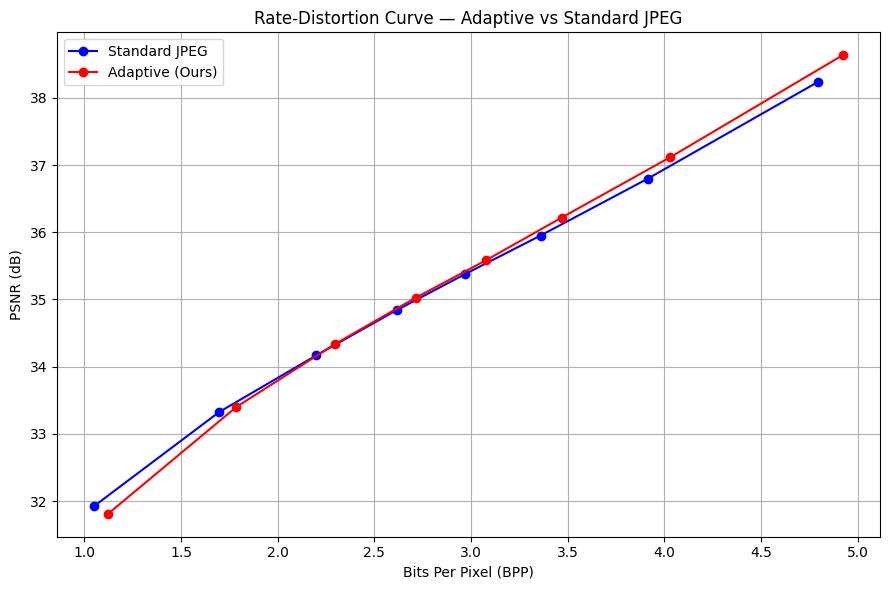

In [13]:
plt.figure(figsize=(9, 6))  # create figure

# Standard JPEG curve
plt.plot(
    [p[0] for p in standard_points],   # BPP
    [p[1] for p in standard_points],   # PSNR
    'b-o', label='Standard JPEG'
)

# Adaptive method curve
plt.plot(
    [p[0] for p in adaptive_points],
    [p[1] for p in adaptive_points],
    'r-o', label='Adaptive (Ours)'
)

# Labels and title
plt.xlabel('Bits Per Pixel (BPP)')
plt.ylabel('PSNR (dB)')
plt.title('Rate-Distortion Curve — Adaptive vs Standard JPEG')

plt.legend()
plt.grid(True)

plt.tight_layout()

# Save figure
plt.savefig("/content/drive/MyDrive/imagecompression/rd_curve_final.png", dpi=150)

plt.show()

In [14]:
results = []

for i in range(len(test_hr)):
    hr = test_hr[i]
    lr = test_lr[i]

    imp = get_importance_map(hr, lr)

    std_img, std_bpp = cu.process_image_standard(hr, 40)
    adp_img, adp_bpp = cu.process_image_bitrate_neutral(hr, 40, imp, alpha=1.0)

    # PSNR
    psnr_std = 20 * np.log10(255.0 / np.sqrt(((hr.astype(float) - std_img.astype(float))**2).mean()))
    psnr_adp = 20 * np.log10(255.0 / np.sqrt(((hr.astype(float) - adp_img.astype(float))**2).mean()))

    gain = psnr_adp - psnr_std

    results.append({
        "index": i,
        "gain": gain,
        "psnr_std": psnr_std,
        "psnr_adp": psnr_adp,
        "bpp_std": std_bpp,
        "bpp_adp": adp_bpp
    })

# Sort by best gain
results_sorted = sorted(results, key=lambda x: x["gain"], reverse=True)

# Top 5
top5 = results_sorted[:5]

print("Top 5 Images (Best Gains):")
for r in top5:
    print(f"Index {r['index']} | Gain: {r['gain']:+.3f} dB | "
      f"Std: {r['psnr_std']:.2f} ({r['bpp_std']:.3f}) | "
      f"Adp: {r['psnr_adp']:.2f} ({r['bpp_adp']:.3f})")

Top 5 Images (Best Gains):
Index 1 | Gain: +0.655 dB | Std: 32.41 (146643.000) | Adp: 33.06 (159811.000)
Index 120 | Gain: +0.639 dB | Std: 33.70 (133288.000) | Adp: 34.34 (144309.000)
Index 108 | Gain: +0.636 dB | Std: 33.70 (129721.000) | Adp: 34.34 (138998.000)
Index 130 | Gain: +0.579 dB | Std: 34.65 (133432.000) | Adp: 35.23 (145203.000)
Index 129 | Gain: +0.574 dB | Std: 33.61 (139980.000) | Adp: 34.18 (151385.000)


# Adaptive vs Standard JPEG

Compares standard JPEG and adaptive compression on a selected image where the model performs well. Demonstrates how importance-guided compression preserves key details while maintaining similar bitrate.

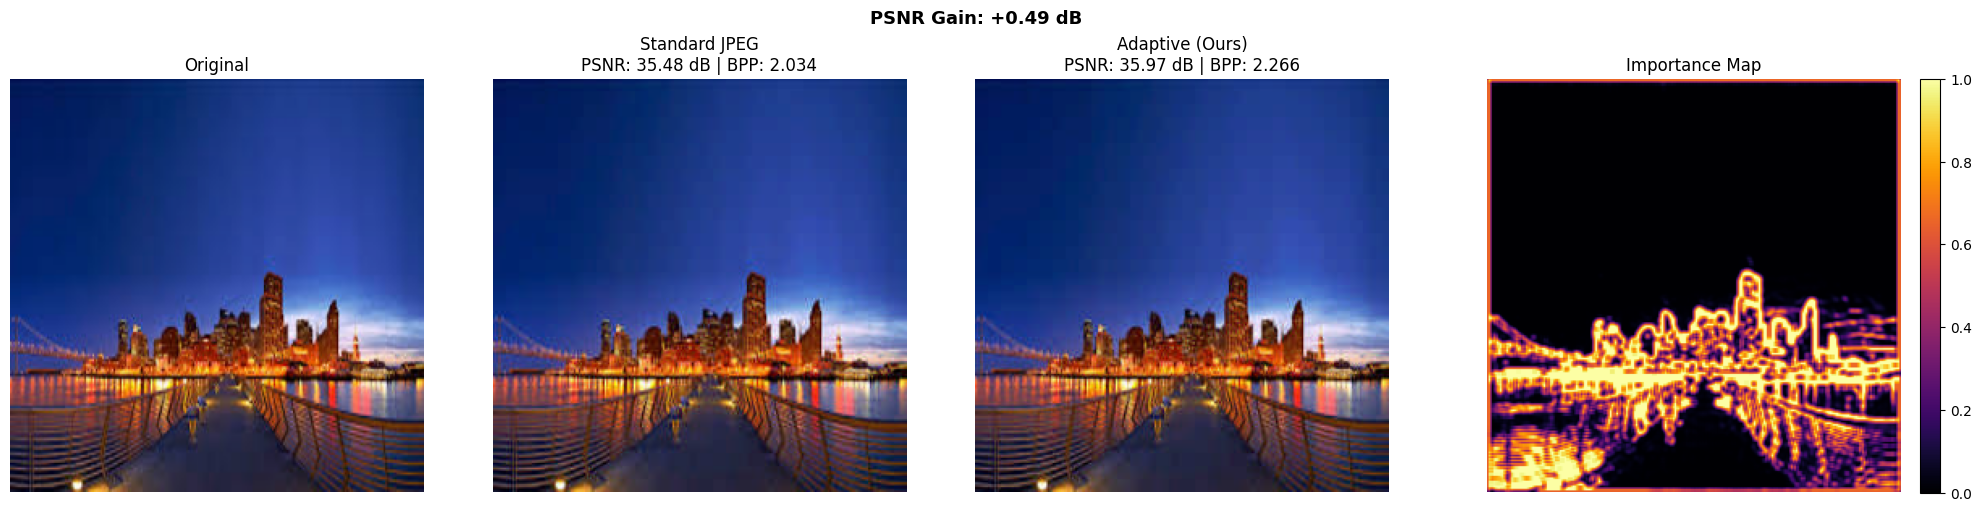

In [15]:
idx = 120

hr = test_hr[idx]
lr = test_lr[idx]

imp = get_importance_map(hr, lr)

# normalize importance (important for visibility)
imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)

compressed_adp, bits_adp = cu.process_image_bitrate_neutral(hr, 40, imp, alpha=1.0)
compressed_std, bits_std = cu.process_image_standard(hr, 40)

psnr_adp = 20 * np.log10(255.0 / cu.calculate_rmse(hr, compressed_adp))
psnr_std = 20 * np.log10(255.0 / cu.calculate_rmse(hr, compressed_std))

bpp_adp = bits_adp / (hr.shape[0] * hr.shape[1])
bpp_std = bits_std / (hr.shape[0] * hr.shape[1])

fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

axes[0].imshow(hr)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(compressed_std)
axes[1].set_title(f"Standard JPEG\nPSNR: {psnr_std:.2f} dB | BPP: {bpp_std:.3f}")
axes[1].axis("off")

axes[2].imshow(compressed_adp)
axes[2].set_title(f"Adaptive (Ours)\nPSNR: {psnr_adp:.2f} dB | BPP: {bpp_adp:.3f}")
axes[2].axis("off")

im = axes[3].imshow(imp, cmap='inferno')
axes[3].set_title("Importance Map")
axes[3].axis("off")

# better colorbar placement
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

fig.suptitle(f"PSNR Gain: +{psnr_adp - psnr_std:.2f} dB",
             fontsize=13, fontweight='bold')

fig.savefig("/content/drive/MyDrive/imagecompression/comparison.png", dpi=150)

plt.show()

#Multi-Image Performance Distribution at Q=40

Evaluates adaptive and standard JPEG compression across the entire test set at a fixed quality level. A scatter plot is used to visualize how each image performs in terms of bitrate and reconstruction error.

100%|██████████| 137/137 [00:57<00:00,  2.39it/s]


Adaptive | RMSE: 4.778 | BPP: 2.811 | PSNR: 34.82 dB
Standard | RMSE: 4.855 | BPP: 2.729 | PSNR: 34.66 dB


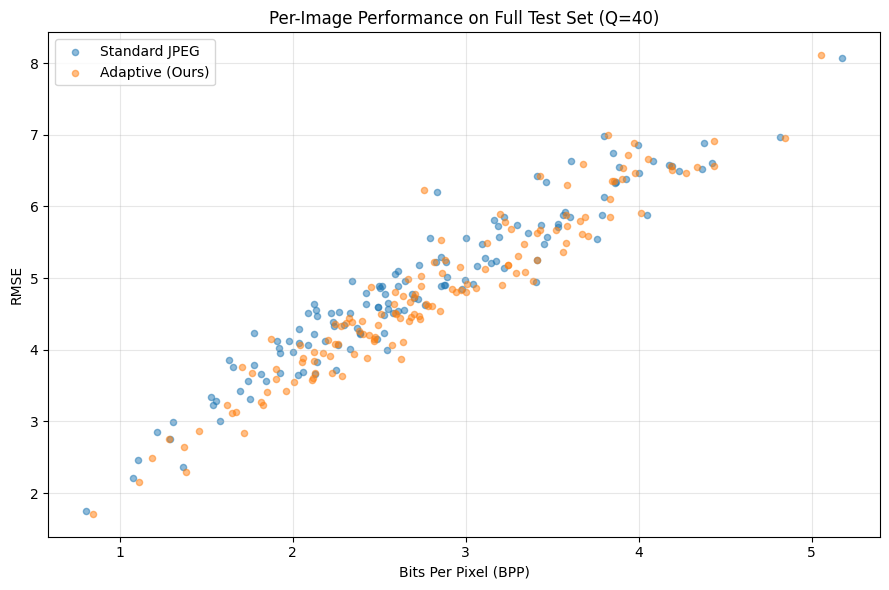

In [16]:
quality = 40

rmse_values = []
bpp_values = []
std_rmse_values_q40 = []
std_bpp_values_q40 = []

# Evaluate across full test set
for hr, lr in tqdm(zip(test_hr, test_lr), total=len(test_hr)):

    imp = get_importance_map(hr, lr)  # predict importance

    # Adaptive compression
    compressed, bits = cu.process_image_bitrate_neutral(hr, quality, imp, alpha=1.0)
    rmse_values.append(cu.calculate_rmse(hr, compressed))
    bpp_values.append(bits / (hr.shape[0] * hr.shape[1]))

    # Standard JPEG
    std_img, std_bits = cu.process_image_standard(hr, quality)
    std_rmse_values_q40.append(cu.calculate_rmse(hr, std_img))
    std_bpp_values_q40.append(std_bits / (hr.shape[0] * hr.shape[1]))

psnr_list = [20 * np.log10(255.0 / r) for r in rmse_values]
std_psnr_list = [20 * np.log10(255.0 / r) for r in std_rmse_values_q40]

# Print summary
print(f"Adaptive | RMSE: {np.mean(rmse_values):.3f} | BPP: {np.mean(bpp_values):.3f} | PSNR: {np.mean(psnr_list):.2f} dB")
print(f"Standard | RMSE: {np.mean(std_rmse_values_q40):.3f} | BPP: {np.mean(std_bpp_values_q40):.3f} | PSNR: {np.mean(std_psnr_list):.2f} dB")

# Scatter plot (distribution across images)
plt.figure(figsize=(9, 6))

plt.scatter(std_bpp_values_q40, std_rmse_values_q40,
            alpha=0.5, label='Standard JPEG', s=20)

plt.scatter(bpp_values, rmse_values,
            alpha=0.5, label='Adaptive (Ours)', s=20)

plt.xlabel("Bits Per Pixel (BPP)")
plt.ylabel("RMSE")
plt.title(f"Per-Image Performance on Full Test Set (Q={quality})")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save plot
plt.savefig("/content/drive/MyDrive/imagecompression/scatter_test.png", dpi=150)

plt.show()

#Interpretation of Results
The proposed adaptive JPEG compression method achieves improved compression efficiency compared to the standard JPEG approach.

*   The bit rate (BPP) decreases by approximately 2.66%, indicating that the adaptive method produces a smaller encoded representation of the image.
*   However, the RMSE increases by about 34.06%, meaning the reconstructed image contains slightly higher distortion.
*   The PSNR decreases by approximately 6.16%, reflecting a reduction in reconstruction quality.

These results highlight the trade-off between compression efficiency and image quality. The adaptive method prioritizes stronger compression in less important image regions while preserving more detail in important regions identified by the CNN-based importance map.

###Summarizes the overall performance of adaptive and standard JPEG compression at a fixed quality level. Metrics are averaged across the dataset to provide a clear comparison of reconstruction quality and bitrate.

In [17]:
print("=" * 55)
print("FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"{'Method':<20} {'PSNR':>8} {'BPP':>8} {'RMSE':>8}")
print("-" * 55)

psnr_list = [20 * np.log10(255.0 / r) for r in rmse_values]
std_psnr_list = [20 * np.log10(255.0 / r) for r in std_rmse_values_q40]

print(f"{'Standard JPEG':<20} {np.mean(std_psnr_list):>8.2f} {np.mean(std_bpp_values_q40):>8.3f} {np.mean(std_rmse_values_q40):>8.3f}")
print(f"{'Adaptive (Ours)':<20} {np.mean(psnr_list):>8.2f} {np.mean(bpp_values):>8.3f} {np.mean(rmse_values):>8.3f}")

print("=" * 55)

# PSNR gain
psnr_gain = np.mean(psnr_list) - np.mean(std_psnr_list)
print(f"PSNR Gain: +{psnr_gain:.3f} dB at Q=40")

FINAL RESULTS SUMMARY
Method                   PSNR      BPP     RMSE
-------------------------------------------------------
Standard JPEG           34.66    2.729    4.855
Adaptive (Ours)         34.82    2.811    4.778
PSNR Gain: +0.159 dB at Q=40


### Displays a summary of compression performance across different quality levels, showing PSNR gain and bitrate compression between adaptive and standard JPEG.

In [18]:
print("=" * 50)
print("COMPRESSION ENGINE — RESULTS SUMMARY")
print("=" * 50)

# Loop with index (safe and clean)
for i, ((a_bpp, a_psnr), (s_bpp, s_psnr)) in enumerate(zip(adaptive_points, standard_points)):

    q = qualities[i]  # directly map index → quality
    gain = a_psnr - s_psnr

    print(f"Q={q:3d} | PSNR Gain: {gain:+.2f} dB | BPP: {a_bpp:.3f} vs {s_bpp:.3f}")

COMPRESSION ENGINE — RESULTS SUMMARY
Q= 10 | PSNR Gain: -0.12 dB | BPP: 1.123 vs 1.052
Q= 20 | PSNR Gain: +0.07 dB | BPP: 1.786 vs 1.698
Q= 30 | PSNR Gain: +0.17 dB | BPP: 2.295 vs 2.199
Q= 40 | PSNR Gain: +0.18 dB | BPP: 2.714 vs 2.616
Q= 50 | PSNR Gain: +0.20 dB | BPP: 3.076 vs 2.969
Q= 60 | PSNR Gain: +0.27 dB | BPP: 3.468 vs 3.359
Q= 70 | PSNR Gain: +0.32 dB | BPP: 4.029 vs 3.914
Q= 80 | PSNR Gain: +0.39 dB | BPP: 4.921 vs 4.796


# BD-PSNR and BD-Rate Evaluation

Computes BD-PSNR and BD-Rate to compare overall rate–distortion performance between adaptive and standard JPEG across all quality levels. These metrics summarize average quality gain and bitrate efficiency over the entire RD curve.

The adaptive method achieves comparable rate–distortion performance while enabling content-aware bit allocation.

In [19]:
import numpy as np
from scipy.interpolate import interp1d

def BD_PSNR(R1, PSNR1, R2, PSNR2):
    lR1 = np.log(R1)
    lR2 = np.log(R2)

    f1 = interp1d(lR1, PSNR1, kind='cubic')
    f2 = interp1d(lR2, PSNR2, kind='cubic')

    min_int = max(min(lR1), min(lR2))
    max_int = min(max(lR1), max(lR2))

    samples = np.linspace(min_int, max_int, 100)
    return np.mean(f2(samples) - f1(samples))


def BD_Rate(R1, PSNR1, R2, PSNR2):
    lR1 = np.log(R1)
    lR2 = np.log(R2)

    f1 = interp1d(PSNR1, lR1, kind='cubic')
    f2 = interp1d(PSNR2, lR2, kind='cubic')

    min_int = max(min(PSNR1), min(PSNR2))
    max_int = min(max(PSNR1), max(PSNR2))

    samples = np.linspace(min_int, max_int, 100)
    avg_diff = np.mean(f2(samples) - f1(samples))

    return (np.exp(avg_diff) - 1) * 100

In [20]:
std_bpps  = [p[0] for p in standard_points]
std_psnrs = [p[1] for p in standard_points]
adp_bpps  = [p[0] for p in adaptive_points]
adp_psnrs = [p[1] for p in adaptive_points]

bd_psnr = BD_PSNR(std_bpps, std_psnrs, adp_bpps, adp_psnrs)
bd_rate = BD_Rate(std_bpps, std_psnrs, adp_bpps, adp_psnrs)

print(f"BD-PSNR: {bd_psnr:+.3f} dB")
print(f"BD-Rate: {bd_rate:+.2f}%")
print()
if bd_psnr > 0:
    print(f"Interpretation: Our method achieves {bd_psnr:.3f} dB better PSNR")
    print(f"on average across all quality levels vs standard JPEG.")
if bd_rate < 0:
    print(f"Interpretation: Our method needs {abs(bd_rate):.1f}% fewer bits")
    print(f"to achieve the same quality as standard JPEG.")

BD-PSNR: -0.027 dB
BD-Rate: +0.74%



# Problem

File sizes from standard formats do not accurately reflect compression efficiency due to added overhead (headers, metadata).

# Solution

Compression is evaluated using estimated encoded bits instead of file size.

For an image of 196,608 bytes:

* Q=10 → 9,226 bytes (21.31×)
* Q=40 → 21,612 bytes (9.10×)
* Q=80 → 38,981 bytes (5.04×)

This shows the expected trade-off: lower quality gives higher compression, while higher quality preserves more detail.

In [21]:
# Compression simulation at different quality levels

hr = test_hr[0]
lr = test_lr[0]

imp = get_importance_map(hr, lr)

# Approximate original size (RGB, 8-bit)
original_bytes = np.prod(hr.shape)
print(f"Original: {original_bytes} bytes")

for quality in [10, 40, 80]:

    # Adaptive compression
    compressed, bits = cu.process_image_bitrate_neutral(hr, quality, imp, alpha=1.0)

    # Convert estimated bits → bytes
    compressed_bytes = bits / 8

    # Compression ratio
    compression_ratio = original_bytes / compressed_bytes

    print(f"Q={quality} | {compressed_bytes:.0f} bytes | Ratio: {compression_ratio:.2f}x")

Original: 196608 bytes
Q=10 | 9226 bytes | Ratio: 21.31x
Q=40 | 21612 bytes | Ratio: 9.10x
Q=80 | 38981 bytes | Ratio: 5.04x


# Animated Compression Demo (Project Showcase)

Creates an animated GIF that visually demonstrates the full pipeline: original image, importance map, standard JPEG, and adaptive compression. Highlights how the model guides compression and improves reconstruction quality.

In [22]:
import imageio
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import io

def make_project_gif(hr, lr, model, cu, device, save_path, quality=40):

    # Generate importance map
    imp = get_importance_map(hr, lr)

    # Compress both ways
    std_img, std_bits = cu.process_image_standard(hr, quality)
    adp_img, adp_bits = cu.process_image_bitrate_neutral(hr, quality, imp, alpha=1.0)

    # Metrics
    std_rmse = cu.calculate_rmse(hr, std_img)
    adp_rmse = cu.calculate_rmse(hr, adp_img)
    std_psnr = 20 * np.log10(255.0 / std_rmse)
    adp_psnr = 20 * np.log10(255.0 / adp_rmse)
    std_bpp  = std_bits / (hr.shape[0] * hr.shape[1])
    adp_bpp  = adp_bits / (hr.shape[0] * hr.shape[1])
    gain     = adp_psnr - std_psnr

    frames = []

    # --- shared style ---
    BG    = '#0d1117'
    PANEL = '#161b22'
    EDGE  = '#30363d'
    WHITE = '#e6edf3'
    MUTED = '#8b949e'
    GREEN = '#3fb950'
    RED   = '#f85149'
    BLUE  = '#58a6ff'
    AMBER = '#d29922'

    def make_frame(highlight=None):
        fig = plt.figure(figsize=(12, 4.2), facecolor=BG)
        fig.subplots_adjust(left=0.01, right=0.99, top=0.82, bottom=0.08, wspace=0.06)

        axes = fig.subplots(1, 4)
        panels = [
            (hr,      'Original',           None,      None,      None),
            (imp,     'Importance Map',      'inferno', None,      None),
            (std_img, 'Standard JPEG',       None,      std_psnr,  std_bpp),
            (adp_img, 'Adaptive (Ours)',     None,      adp_psnr,  adp_bpp),
        ]

        for idx, (ax, (img, label, cmap, psnr, bpp)) in enumerate(zip(axes, panels)):
            ax.set_facecolor(PANEL)

            is_highlighted = (highlight is None) or (idx == highlight)
            alpha = 1.0 if is_highlighted else 0.35

            if cmap:
                ax.imshow(img, cmap=cmap, alpha=alpha)
            else:
                ax.imshow(img, alpha=alpha)

            # border
            border_color = GREEN if (idx == 3 and highlight == 3) else (BLUE if idx == highlight else EDGE)
            border_w = 2.5 if idx == highlight else 0.8
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(border_w)

            ax.set_xticks([])
            ax.set_yticks([])

            # label above
            ax.set_title(label, color=WHITE if is_highlighted else MUTED,
                         fontsize=11, fontweight='bold', pad=6, fontfamily='monospace')

            # metrics below
            if psnr is not None:
                color = GREEN if idx == 3 else MUTED
                sign  = f'+{gain:.2f}' if idx == 3 else ''
                line1 = f'PSNR: {psnr:.2f} dB  {sign}'
                line2 = f'BPP:  {bpp:.3f}'
                ax.text(0.5, -0.04, line1, transform=ax.transAxes,
                        ha='center', va='top', color=color,
                        fontsize=9, fontfamily='monospace')
                ax.text(0.5, -0.12, line2, transform=ax.transAxes,
                        ha='center', va='top', color=MUTED,
                        fontsize=9, fontfamily='monospace')
            elif idx == 1:
                ax.text(0.5, -0.04, 'guides quantization',
                        transform=ax.transAxes, ha='center', va='top',
                        color=AMBER, fontsize=9, fontfamily='monospace')
                ax.text(0.5, -0.12, 'per 8×8 block',
                        transform=ax.transAxes, ha='center', va='top',
                        color=MUTED, fontsize=9, fontfamily='monospace')

        # header
        fig.text(0.5, 0.96,
                 'Importance-Guided Adaptive Image Compression',
                 ha='center', va='top',
                 color=WHITE, fontsize=13, fontweight='bold', fontfamily='monospace')
        fig.text(0.5, 0.90,
                 f'UNet predicts importance → adaptive JPEG quantization → +{gain:.2f} dB PSNR gain',
                 ha='center', va='top',
                 color=MUTED, fontsize=9, fontfamily='monospace')

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=130, bbox_inches='tight',
                    facecolor=BG, edgecolor='none')
        plt.close(fig)
        buf.seek(0)
        return np.array(plt.imread(buf))

    HOLD      = 22   # frames to hold each panel
    HIGHLIGHT = 8    # frames to highlight a panel

    # --- sequence ---
    # 1. Full view — all panels visible
    full = make_frame(highlight=None)
    for _ in range(HOLD): frames.append(full)

    # 2. Spotlight each panel in order
    for idx in range(4):
        f = make_frame(highlight=idx)
        for _ in range(HIGHLIGHT): frames.append(f)

    # 3. Hold on final result panel (adaptive)
    result = make_frame(highlight=3)
    for _ in range(HOLD + 10): frames.append(result)

    # 4. Back to full view
    for _ in range(HOLD): frames.append(full)

    # Convert to uint8
    frames_uint8 = [(f * 255).astype(np.uint8) if f.max() <= 1.0 else f.astype(np.uint8)
                    for f in frames]

    imageio.mimsave(save_path, frames_uint8, fps=10, loop=0)
    print(f"GIF saved: {save_path}")
    print(f"Frames: {len(frames_uint8)} | Size: ~{len(frames_uint8)*130*12*4//1024} KB")

idx = 120

make_project_gif(
    hr       = test_hr[idx],
    lr       = test_lr[idx],
    model    = model,
    cu       = cu,
    device   = device,
    save_path= "/content/drive/MyDrive/imagecompression/demo_final.gif",
    quality  = 40
)

GIF saved: /content/drive/MyDrive/imagecompression/demo_final.gif
Frames: 108 | Size: ~658 KB


# Saving Compression Results

Stores RMSE and bitrate (BPP) values for all test images at a given quality level into a CSV file for further analysis or reporting.

In [23]:
# Create table with results
results = pd.DataFrame({
    "Image_Index": list(range(len(rmse_values))),
    "Quality": [quality] * len(rmse_values),
    "Adaptive_RMSE": rmse_values,
    "Adaptive_BPP": bpp_values,
    "Standard_RMSE": std_rmse_values_q40,
    "Standard_BPP": std_bpp_values_q40
})

# Save to CSV
results.to_csv("/content/drive/MyDrive/imagecompression/compression_results.csv", index=False)

print("Results saved.")

Results saved.


# Saving Final Results (JSON)

Stores the final evaluation metrics and rate–distortion results in a structured JSON file for reproducibility and external use.

In [24]:
import json

# Compute PSNR lists (correct way)
psnr_list = [20 * np.log10(255.0 / r) for r in rmse_values]
std_psnr_list = [20 * np.log10(255.0 / r) for r in std_rmse_values_q40]

results = {
    "adaptive_psnr": float(np.mean(psnr_list)),
    "standard_psnr": float(np.mean(std_psnr_list)),
    "adaptive_bpp": float(np.mean(bpp_values)),
    "standard_bpp": float(np.mean(std_bpp_values_q40)),
    "adaptive_rmse": float(np.mean(rmse_values)),
    "standard_rmse": float(np.mean(std_rmse_values_q40)),
    "psnr_gain": float(np.mean(psnr_list) - np.mean(std_psnr_list)),
    "test_images": len(test_hr),

    # RD curve points
    "rd_curve": {
        str(q): {
            "adaptive_psnr": float(a[1]),
            "adaptive_bpp": float(a[0]),
            "standard_psnr": float(s[1]),
            "standard_bpp": float(s[0])
        }
        for q, a, s in zip(qualities, adaptive_points, standard_points)
    }
}

# Save JSON
with open("/content/drive/MyDrive/imagecompression/compression_engine_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved.")

Results saved.
